In [1]:
from model import *
from torchinfo import summary
from PIL import Image
import torchvision.transforms as T
import numpy as np
from people_dataset import *
import sys
sys.path.append('core')
import argparse
import glob
import numpy as np
import torch
from tqdm import tqdm
from pathlib import Path
from core.defom_stereo import DEFOMStereo
from utils.utils import InputPadder
from matplotlib import pyplot as plt
import cv2
import gc
from scipy import ndimage
DEVICE="cpu"
class PredictParameters():
    def __init__(self):
        self.parser = argparse.ArgumentParser()
        self.parser.add_argument('--mixed_precision', action='store_true', help='use mixed precision')
        self.parser.add_argument('--valid_iters', type=int, default=32, help='number of flow-field updates during forward pass')
        self.parser.add_argument('--scale_iters', type=int, default=8, help="number of scaling updates to the disparity field in each forward pass.")
        # DefomStereo Architecture choices
        self.parser.add_argument('--dinov2_encoder', type=str, default='vitl', choices=['vits', 'vitb', 'vitl', 'vitg'])
        self.parser.add_argument('--idepth_scale', type=float, default=0.5, help="the scale of inverse depth to initialize disparity")
        self.parser.add_argument('--hidden_dims', nargs='+', type=int, default=[128]*3, help="hidden state and context dimensions")
        self.parser.add_argument('--corr_implementation', choices=["reg", "alt", "reg_cuda", "alt_cuda"], default="reg", help="correlation volume implementation")
        self.parser.add_argument('--shared_backbone', action='store_true', help="use a single backbone for the context and feature encoders")
        self.parser.add_argument('--corr_levels', type=int, default=2, help="number of levels in the correlation pyramid")
        self.parser.add_argument('--corr_radius', type=int, default=4, help="width of the correlation pyramid")
        self.parser.add_argument('--scale_list', type=float, nargs='+', default=[0.125, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0],
                            help='the list of scaling factors of disparity')
        self.parser.add_argument('--scale_corr_radius', type=int, default=2,
                            help="width of the correlation pyramid for scaled disparity")
        self.parser.add_argument('--n_downsample', type=int, default=2, choices=[2, 3], help="resolution of the disparity field (1/2^K)")
        self.parser.add_argument('--context_norm', type=str, default="batch", choices=['group', 'batch', 'instance', 'none'], help="normalization of context encoder")
        self.parser.add_argument('--n_gru_layers', type=int, default=3, help="number of hidden GRU levels")
    def parse(self):
        self.args,_=self.parser.parse_known_args()
        return self.args 
def show_save_predict_right(left,model,output_dir="assets/right_predict.png"):
    origin_shape=(left.size[1],left.size[0])
    transform=T.Compose([T.ToTensor(),T.Resize((256,512)),T.Normalize(mean=[0.5],std=[0.5])])
    left=transform(left)
    predict_right=model(left.unsqueeze(0)).detach()
    resize=T.Resize((origin_shape))
    predict_right=resize(predict_right).squeeze().numpy().transpose(1,2,0)
    predict_right = (predict_right*255.0).astype(np.uint8)
    pil_image = Image.fromarray(predict_right)
    pil_image.save(output_dir)
    fig_width = origin_shape[1] / 100  # 宽度除以dpi
    fig_height = origin_shape[0] / 100  # 高度除以dpi
    plt.figure(figsize=(fig_width, fig_height))
    plt.imshow(predict_right)
    plt.axis('off')
def save_predict_right(left,model,output_dir="assets/right_predict.png"):
    origin_shape=(left.size[1],left.size[0])
    transform=T.Compose([T.ToTensor(),T.Resize((256,512)),T.Normalize(mean=[0.5],std=[0.5])])
    left=transform(left)
    predict_right=model(left.unsqueeze(0)).detach()
    resize=T.Resize((origin_shape))
    predict_right=resize(predict_right).squeeze().numpy().transpose(1,2,0)
    predict_right = (predict_right*255.0).astype(np.uint8)
    pil_image = Image.fromarray(predict_right)
    pil_image.save(output_dir)
def show_common_img(img):
    img_shape=(img.size[1],img.size[0])
    fig_width=img_shape[1]/100
    fig_height=img_shape[0]/100
    print(f"宽:{fig_width}")
    print(f"高:{fig_height}")
    plt.figure(figsize=(fig_width,fig_height))
    plt.imshow(np.array(img))
    plt.axis('off')
def show_predict_depth(depth_img):
    img_shape=(depth_img.shape[1],depth_img.shape[0])
    fig_width=img_shape[0]/100
    fig_height=img_shape[1]/100
    plt.figure(figsize=(fig_width,fig_height))
    plt.imshow(depth_img,cmap="gray")
    plt.axis('off')
def predict_right(left,model):
    if isinstance(left.size,int):
        origin_shape=(left.shape[1],left.shape[0])
    else:
        origin_shape=(left.size[1],left.size[0])
    transform=T.Compose([T.ToTensor(),T.Resize((256,512)),T.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])
    left=transform(left)
    predict_right=model(left.unsqueeze(0)).detach()
    resize=T.Resize((origin_shape))
    predict_right=resize(predict_right).squeeze().numpy().transpose(1,2,0)
    predict_right = (predict_right*255.0).astype(np.uint8)
    predict_right = torch.from_numpy(predict_right).permute(2, 0, 1).float()
    predict_right=predict_right[None].to(DEVICE)
    predict_right=sharpen_image(predict_right)
    return predict_right
def depth_to_uint8(depth_map, max_depth=255.0):
    depth_clipped = torch.clamp(depth_map, 0, max_depth)
    depth_normalized = depth_clipped / max_depth
    depth_uint8 = (depth_normalized * 255).byte()
    return depth_uint8
def predict_depth(left,model_predict_right,model_predict_disp,args,right=None):
    left_img = np.array(left).astype(np.uint8)
    left_img = torch.from_numpy(left_img).permute(2, 0, 1).float()
    left_img=left_img[None].to(DEVICE)
    if right==None:
        right_img=predict_right(left,model_predict_right)
    else:
        right_img = np.array(right).astype(np.uint8)
        right_img = torch.from_numpy(right_img).permute(2, 0, 1).float()
        right_img=right_img[None].to(DEVICE)
    padder = InputPadder(left_img.shape, divis_by=32)
    left_img, right_img = padder.pad(left_img, right_img)
    #right_ones=torch.ones_like(right_img)
    with torch.no_grad():
        disp=model_predict_disp(left_img, right_img, iters=args.valid_iters, scale_iters=args.scale_iters, test_mode=True).detach()
    focal_length = 600.0  # 相机焦距（像素单位）
    baseline = 1         # 立体相机基线距离（米）
    depth_map = (focal_length * baseline) / (disp.squeeze()+ 1e-8)
    depth_map=depth_to_uint8(depth_map).numpy()
    return depth_map
def slice_for_depth_estimation(image_path, model_predict_right,model_predict_disp, args,patch_size=128):
    image = cv2.imread(image_path)
    h, w = image.shape[:2]
    
    patches = []
    depth_patches = []
    positions = []
    
    # 创建重叠网格
    stride = patch_size
    rows=0
    cols=0
    for y in range(0, h, stride):
        cols=0
        for x in range(0, w, stride):
            # 调整边界
            end_y = min(y + patch_size, h)
            end_x = min(x + patch_size, w)
            start_y = end_y - patch_size
            start_x = end_x - patch_size
            
            if start_y < 0: start_y = 0
            if start_x < 0: start_x = 0
            
            patch = image[start_y:end_y, start_x:end_x]
            
            # 如果切片太小，跳过
            if patch.shape[0] < patch_size // 2 or patch.shape[1] < patch_size // 2:
                continue
            # 调整到标准尺寸
            if patch.shape != (patch_size, patch_size, 3):
                patch = cv2.resize(patch, (patch_size, patch_size))
            patches.append(patch)
            cols+=1
            positions.append((start_x, start_y, end_x, end_y))
        rows+=1
    # 对每个切片进行深度估计
    print(f"分了{len(patches)}片")
    for patch in patches:
        # 这里调用你的深度估计模型
        depth_map = predict_depth(patch,model_predict_right,model_predict_disp,args)
        depth_patches.append(depth_map)
    return patches, depth_patches, positions,rows,cols
def sharpen_image(img, alpha=0.3):
        # Laplacian锐化核
        kernel = torch.tensor([[-1,-1,-1],[-1,9,-1],[-1,-1,-1]],dtype=img.dtype,device=img.device)
        kernel = kernel.unsqueeze(0).unsqueeze(0).repeat(img.shape[1],1,1,1)
        sharp = F.conv2d(img, kernel, padding=1, groups=img.shape[1])
        img = img*(1-alpha) + sharp*alpha
        return torch.clamp(img, 0, 1)
def img_reconstruct(patches, nrows=8, ncols=12, patch_size=None):
    if patch_size is None:
        # 从第一个patch获取尺寸
        patch_size = patches[0].shape[:2]
    
    # 创建空白画布
    reconstructed = np.zeros((nrows * patch_size[0], ncols * patch_size[1]), dtype=patches[0].dtype)
    
    # 按网格顺序填充
    for i, patch in enumerate(patches):
        if i >= nrows * ncols:
            break
            
        row = i // ncols
        col = i % ncols
        
        start_row = row * patch_size[0]
        end_row = start_row + patch_size[0]
        start_col = col * patch_size[1]
        end_col = start_col + patch_size[1]
        
        reconstructed[start_row:end_row, start_col:end_col] = patch
    
    return reconstructed
def create_precise_boundary_mask(image_shape, nrows=8, ncols=12, patch_size=512, mask_width=15):
    """
    创建精确的patch边界掩码
    """
    h, w = image_shape[:2] if len(image_shape) == 3 else image_shape
    mask = np.zeros((h, w), dtype=np.uint8)
    
    # 垂直边界
    for col in range(1, ncols):
        x = col * patch_size
        start_x = max(0, x - mask_width)
        end_x = min(w, x + mask_width)
        mask[:, start_x:end_x] = 255
    
    # 水平边界
    for row in range(1, nrows):
        y = row * patch_size
        start_y = max(0, y - mask_width)
        end_y = min(h, y + mask_width)
        mask[start_y:end_y, :] = 255
    
    return mask
def inpaint_with_selective_blur(image, boundary_mask):
    """修复后对边界区域进行选择性模糊"""
    # 先修复
    repaired = cv2.inpaint(image, boundary_mask,30, cv2.INPAINT_TELEA)
    
    # 创建模糊掩码（比修复掩码稍宽）
    blur_mask = cv2.dilate(boundary_mask, np.ones((32,32), np.uint8), iterations=2)
    
    # 对边界区域应用高斯模糊
    blurred = cv2.GaussianBlur(repaired, (34, 34), 5)
    
    # 修复形状匹配问题
    if len(image.shape) == 2:  # 灰度图
        # 确保blur_mask是2D的
        result = np.where(blur_mask > 0, blurred, repaired)
    else:  # 彩色图
        # 扩展blur_mask到3通道
        blur_mask_3d = np.repeat(blur_mask[:, :, np.newaxis], 3, axis=2)
        result = np.where(blur_mask_3d > 0, blurred, repaired)
    
    return result

xFormers not available
xFormers not available


In [22]:
predict_parser=PredictParameters()
args=predict_parser.parse()
model_predict_right=GeometryAwareStereoGenerator()
model_predict_disp=DEFOMStereo(args)

In [28]:
model_predict_right.load_state_dict(torch.load('models/right_generator/fifth_my_right_generator_GAN.pth',map_location=torch.device('cpu'),weights_only=True ))
model_predict_disp.load_state_dict(torch.load('models/defom_stereo/defomstereo_vitl_kitti.pth',map_location=torch.device('cpu'),weights_only=True ))
with torch.no_grad():
    model_predict_right.eval()
    model_predict_disp.eval()

In [29]:
test_left=Image.open("assets/lefts/left_20.png")
#test_left=Image.open("assets/t1_low.jpg")
test_right=Image.open("assets/rights/right_20.png")

宽:12.42
高:3.75


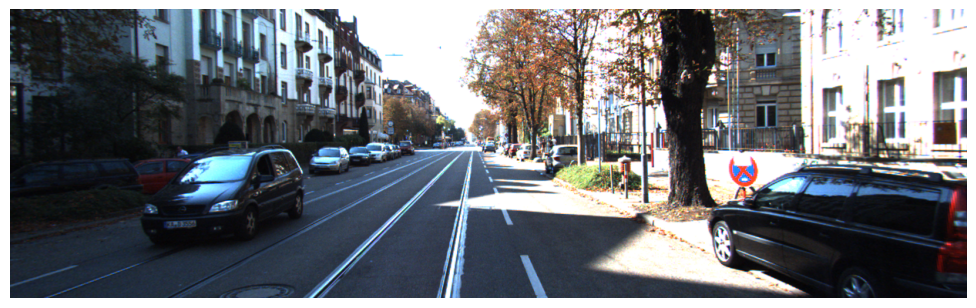

In [30]:
show_common_img(test_left)

宽:12.42
高:3.75


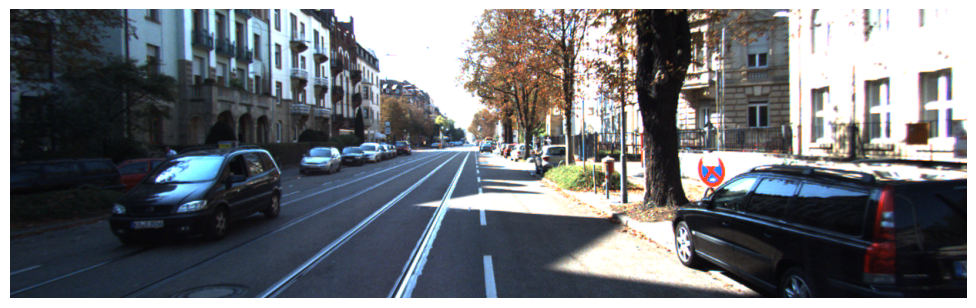

In [31]:
show_common_img(test_right)

用时:0.400秒


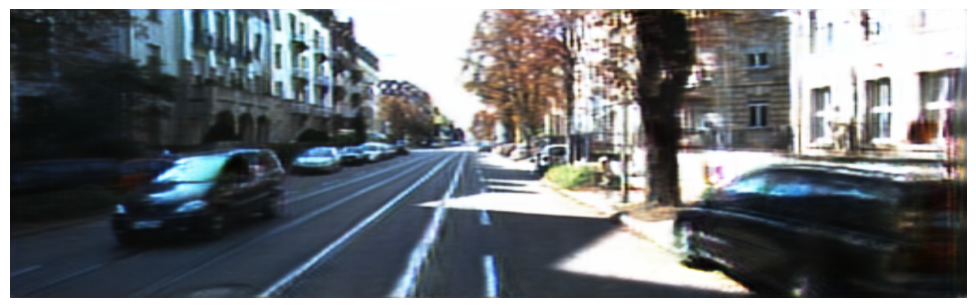

In [32]:
start_time=time.time()
show_save_predict_right(test_left,model_predict_right,output_dir="assets/right_predict_1.png")
end_time=time.time()-start_time
print(f"用时:{end_time:.3f}秒")

In [36]:
depth_predict=predict_depth(test_left,model_predict_right,model_predict_disp,args)

(np.float64(-0.5), np.float64(1247.5), np.float64(383.5), np.float64(-0.5))

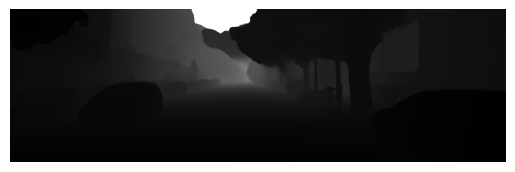

In [37]:
plt.imshow(depth_predict,cmap='gray')
plt.axis('off')

In [38]:
Image.fromarray(depth_predict).save(f"assets/depths_predict_right/depth_20.png")

In [ ]:
def temp():
    for i in range(15):
        test_left=Image.open(f"assets/lefts/left_{i}.png")
        test_right=Image.open(f"assets/rights/right_{i}.png")
        depth=predict_depth(test_left,model_predict_right,model_predict_disp,args,test_right)
        Image.fromarray(depth).save(f"assets/depths_truth_right/depth_{i}.png")

In [21]:
temp()